In [27]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

#Load the data
df = pd.read_csv(url)

#Explore the data
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

In [28]:
#Check for missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [29]:
#Cleaning the Data
df["Glucose"] = df["Glucose"].replace(0, df["Glucose"].median())
df["BloodPressure"] = df["BloodPressure"].replace(0, df["BloodPressure"].median())
df["SkinThickness"] = df["SkinThickness"].replace(0, df["SkinThickness"].median())
df["Insulin"] = df["Insulin"].replace(0, df["Insulin"].median())
df["BMI"] = df["BMI"].replace(0, df["BMI"].median())
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [30]:
#All are values, therefore theres no need to encode
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

#Define the data
X = df.drop('Outcome', axis=1)
y = df['Outcome']

#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

#Standardizing
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#Make predictions
y_pred = model.predict(X_test)

#Evaluate the model
score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
classification= classification_report(y_test, y_pred)

#Print out the results
print(f"The model has an accuracy score of {100 * score:.2f}%")
print(f"\nConfusion matrix:\n{cm}")
print(f"\nClassification Report:\n{classification}")

The model has an accuracy score of 70.78%

Confusion matrix:
[[82 18]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



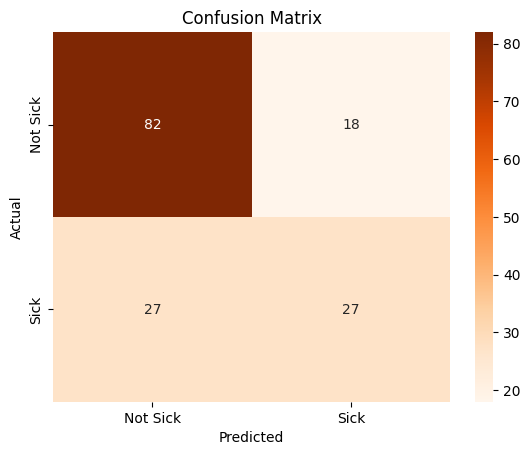

In [31]:

#Visualizing the cm
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, fmt='d',
          annot= True, cmap="Oranges",
          xticklabels=["Not Sick", "Sick"],
          yticklabels=["Not Sick", "Sick"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
new_patients = pd.DataFrame({
"Pregnancies": [3, 2, 1],
"Glucose": [95, 155, 245],
"BloodPressure": [70, 89, 98],
"SkinThickness": [18, 30, 45],
"Insulin": [20, 166, 40],
"BMI": [30, 27.5, 20],
"DiabetesPedigreeFunction": [0.25, 0.55, 1.25],
"Age": [25, 40, 19]
})

new_patients = scaler.fit_transform(new_patients)
pred = model.predict(new_patients)
prob = model.predict_proba(new_patients)
print(pred)

for i, (pred, prob) in enumerate(zip(pred, prob)):
    status = "Not Sick" if pred == 0 else "Sick"
    probability = round(prob.max(), 2) * 100
    print(f"There is a {probability}% chance that Patient {i+1} is {status}")

[0 0 0]
There is a 78.0% chance that Patient 1 is Not Sick
There is a 71.0% chance that Patient 2 is Not Sick
There is a 62.0% chance that Patient 3 is Not Sick
